In [ ]:
#Decision Tree

    pH  Temprature  Taste  Odor  Fat   Turbidity  Colour   Grade
0  6.6          35      1     0     1          0     254    high
1  6.6          36      0     1     0          1     253    high
2  8.5          70      1     1     1          1     246     low
3  9.5          34      1     1     0          1     255     low
4  6.6          37      0     0     0          0     255  medium
Performing 5-fold Cross-Validation...

Cross-Validated Accuracy: 0.9943342776203966
Cross-Validated Precision: 0.9943344753685669
Confusion Matrix:
 [[252   1   3]
 [  1 428   0]
 [  1   0 373]]


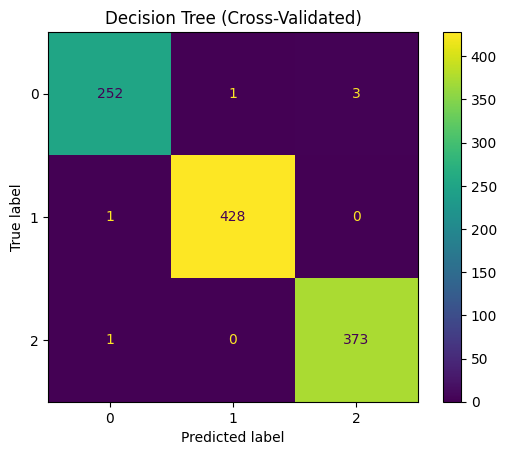

In [ ]:
# ============================================================
# Step 1: Import Libraries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score
import numpy as np


# ============================================================
# Step 2: Load Dataset
# ============================================================

df = pd.read_csv("milknew.csv")   # <-- put your file name here

print(df.head())


# ============================================================
# Step 3: Data Preprocessing
# ============================================================


# Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


# ============================================================
# Step 4: Split Data
# ============================================================


target_column = df.columns[-1]   # assuming last column is target

X = df.drop(target_column, axis=1)
y = df[target_column]


# ============================================================
# Step 5: Initialize Decision Tree Model
# ============================================================

model model= DecisionTreeClassifier(random_state=42)


# ============================================================
# Step 6: Cross-Validation
# ============================================================

print("Performing 5-fold Cross-Validation...")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(model, X, y, cv=kf)


# ============================================================
# Step 7: Evaluation
# ============================================================

accuracy_cv = accuracy_score(y, y_pred_cv)
print("\nCross-Validated Accuracy:", accuracy_cv)

precision_cv = precision_score(y, y_pred_cv, average='weighted')
print("Cross-Validated Precision:", precision_cv)

cm_cv = confusion_matrix(y, y_pred_cv)
print("Confusion Matrix:\n", cm_cv)

ConfusionMatrixDisplay.from_predictions(y, y_pred_cv)
plt.title("Decision Tree (Cross-Validated)")
plt.show()

    pH  Temprature  Taste  Odor  Fat   Turbidity  Colour   Grade
0  6.6          35      1     0     1          0     254    high
1  6.6          36      0     1     0          1     253    high
2  8.5          70      1     1     1          1     246     low
3  9.5          34      1     1     0          1     255     low
4  6.6          37      0     0     0          0     255  medium
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pH          1059 non-null   float64
 1   Temprature  1059 non-null   int64  
 2   Taste       1059 non-null   int64  
 3   Odor        1059 non-null   int64  
 4   Fat         1059 non-null   int64  
 5   Turbidity   1059 non-null   int64  
 6   Colour      1059 non-null   int64  
 7   Grade       1059 non-null   object 
dtypes: float64(1), int64(6), object(1)
memory usage: 66.3+ KB
None

--- Test Set Evaluation -

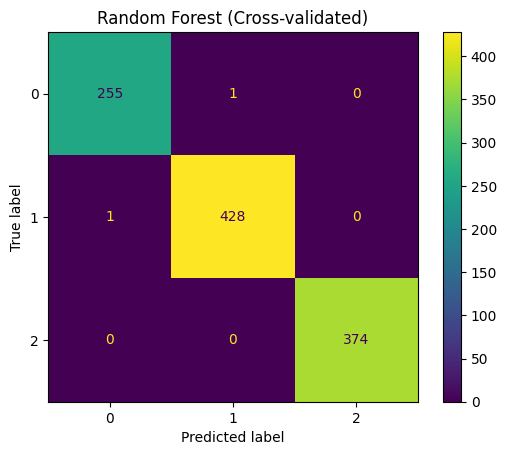

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score


# ============================================================
# Step 1: Load Dataset
# ============================================================

df = pd.read_csv("milknew.csv")   # <-- your dataset

print(df.head())
print(df.info())


# ============================================================
# Step 2: Data Preprocessing
# ============================================================

# Drop unnecessary columns if present
# Example (edit if needed):
# df = df.drop(columns=["Id"])

# Encode categorical columns
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


# ============================================================
# Step 3: Define Features and Target
# ============================================================

# IMPORTANT: Replace with your actual target column if different
target_column = df.columns[-1]   # assuming last column is target

X = df.drop(target_column, axis=1)
y = df[target_column]


# ============================================================
# Step 4: Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# ============================================================
# Step 5: Train Random Forest Model
# ============================================================

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# ============================================================
# Step 6: Test Accuracy
# ============================================================

y_pred = model.predict(X_test)

print("\n--- Test Set Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))


# ============================================================
# Step 7: Cross-Validation
# ============================================================

print("\n--- Cross-validated Model Evaluation ---")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Accuracy
cv_accuracy_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
print("CV Accuracy Scores:", cv_accuracy_scores)
print("Mean CV Accuracy:", cv_accuracy_scores.mean())

# Precision
cv_precision_scores = cross_val_score(model, X, y, cv=skf, scoring='precision_weighted')
print("CV Precision Scores:", cv_precision_scores)
print("Mean CV Precision:", cv_precision_scores.mean())


# ============================================================
# Step 8: Confusion Matrix (Cross-validated)
# ============================================================

y_pred_cv = cross_val_predict(model, X, y, cv=skf)

cm_cv = confusion_matrix(y, y_pred_cv)
print("\nConfusion Matrix:\n", cm_cv)

ConfusionMatrixDisplay.from_predictions(y, y_pred_cv)
plt.title("Random Forest (Cross-validated)")
plt.show()

    pH  Temprature  Taste  Odor  Fat   Turbidity  Colour   Grade
0  6.6          35      1     0     1          0     254    high
1  6.6          36      0     1     0          1     253    high
2  8.5          70      1     1     1          1     246     low
3  9.5          34      1     1     0          1     255     low
4  6.6          37      0     0     0          0     255  medium

Columns: Index(['pH', 'Temprature', 'Taste', 'Odor', 'Fat ', 'Turbidity', 'Colour',
       'Grade'],
      dtype='object')

Target Column: Grade


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Cross-Validation Accuracy Scores: [0.73584906 0.79716981 0.82075472 0.78301887 0.78199052]
Mean CV Accuracy: 0.7838
Standard Deviation: 0.0277


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Cross-validated Confusion Matrix:
 [[200  55   1]
 [ 61 331  37]
 [ 25  50 299]]


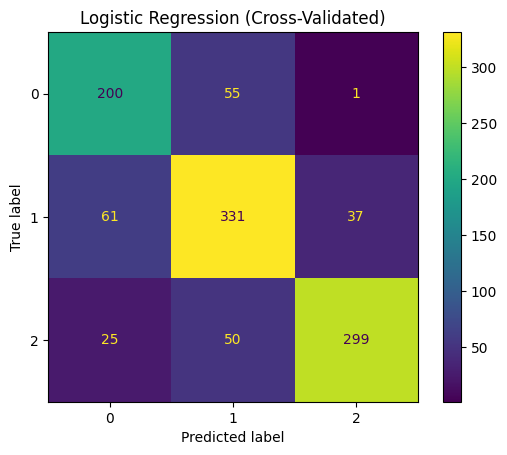

In [ ]:
# ============================================================
# Step 1: Import Libraries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# ============================================================
# Step 2: Load Dataset
# ============================================================

df = pd.read_csv("milknew.csv")   # <-- your dataset
print(df.head())
print("\nColumns:", df.columns)


# ============================================================
# Step 3: Data Preprocessing
# ============================================================

# Drop ID column IF exists
for col in df.columns:
    if "id" in col.lower():
        df = df.drop(columns=[col])

# Encode categorical data
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


# ============================================================
# Step 4: Define Target Automatically
# ============================================================

# Assuming LAST column is target (common case)
target_column = df.columns[-1]

print("\nTarget Column:", target_column)

X = df.drop(target_column, axis=1)
y = df[target_column]


# ============================================================
# Step 5: Model
# ============================================================

model = LogisticRegression(max_iter=1000)


# ============================================================
# Step 6: Cross-Validation
# ============================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print("\nCross-Validation Accuracy Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")


# ============================================================
# Step 7: Cross-Validated Predictions
# ============================================================

y_pred_cv = cross_val_predict(model, X, y, cv=kf)


# ============================================================
# Step 8: Confusion Matrix
# ============================================================

cm_cv = confusion_matrix(y, y_pred_cv)

print("\nCross-validated Confusion Matrix:\n", cm_cv)

ConfusionMatrixDisplay.from_predictions(y, y_pred_cv)
plt.title("Logistic Regression (Cross-Validated)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression Accuracy: 0.7838
Decision Tree Accuracy: 0.9972
Random Forest Accuracy: 0.9972


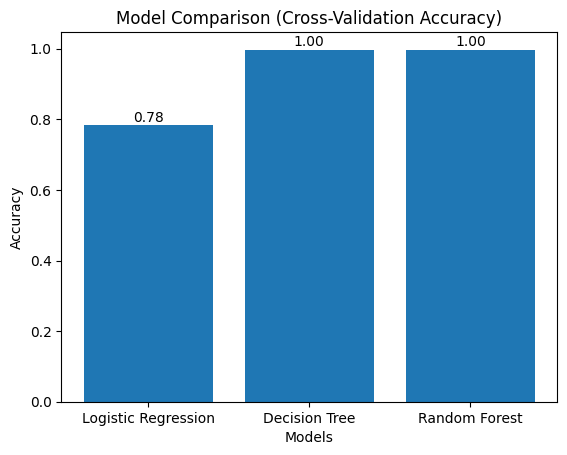

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

model_names = []
accuracies = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    mean_acc = scores.mean()

    model_names.append(name)
    accuracies.append(mean_acc)

    print(f"{name} Accuracy: {mean_acc:.4f}")


# ============================================================
# Plot Accuracy Graph
# ============================================================

plt.figure()

plt.bar(model_names, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Cross-Validation Accuracy)")

# Add values on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()